# Task 1 — Exploratory Data Analysis & Preprocessing

**Goal:** understand the raw CFPB complaint dataset, then filter and clean it down to
the four products CrediTrust cares about, ready for chunking/embedding in Task 2.

This notebook uses the **memory-safe streaming functions** in `src/data_processing.py`
(`run_eda_streaming`, `load_and_filter`) rather than loading the full raw CSV into
memory at once. This matters for two reasons:
1. The full CFPB export can be several GB — loading it whole can exhaust RAM on a
   typical laptop.
2. Reading only the first N rows (`nrows=`) biases the sample toward whatever the
   file happens to be sorted by (usually most-recent-first), which skews product
   distribution and narrative coverage. Streaming scans the *entire* file in
   bounded-memory chunks instead.

**Input:** `data/raw/complaints.csv` (the full CFPB complaint export)
**Output:** `data/processed/filtered_complaints.csv`


In [7]:
import sys
sys.path.append("..")  # so `import src` works when running from notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_processing import run_eda_streaming, load_and_filter, clean_text

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 1. Product taxonomy note

CFPB has renamed several product categories over time. Our four target products map
to the *current* raw category names like this (see `config.TARGET_PRODUCT_KEYWORDS`):

| CrediTrust category | Matches raw Product values containing... |
|---|---|
| Credit card | "credit card" |
| Personal loan | "personal loan", "payday loan", "title loan" |
| Savings account | "savings account", "checking or savings" |
| Money transfer | "money transfer" |

`_map_to_target_product()` does keyword matching rather than an exact string
comparison, so this keeps working even if CFPB renames a category again.

In [8]:
config.TARGET_PRODUCT_KEYWORDS

{'Credit card': ['credit card'],
 'Personal loan': ['personal loan', 'payday loan', 'title loan'],
 'Savings account': ['savings account', 'checking or savings'],
 'Money transfer': ['money transfer']}

## 2. Run EDA across the full raw file (streaming)

This scans every row of `complaints.csv` in 50,000-row chunks, accumulating product counts, narrative-coverage counts, and narrative word-count stats — without ever holding the whole file in memory at once. Depending on file size this can take a minute or two; progress logs print every 10 chunks.

In [9]:
eda_stats = run_eda_streaming()

print("Product counts (full raw dataset, all CFPB categories):")
eda_stats["product_counts"]

2026-07-11 10:11:13,187 - INFO - Streaming D:\10 acadamy\rag-complaint-chatbot\data\raw\complaints.csv for EDA


d:\10 acadamy\rag-complaint-chatbot\notebooks\..\src\data_processing.py:173: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
2026-07-11 10:24:11,534 - INFO - With narrative: 2,980,756 | Without narrative: 6,629,041


Product counts (full raw dataset, all CFPB categories):


Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

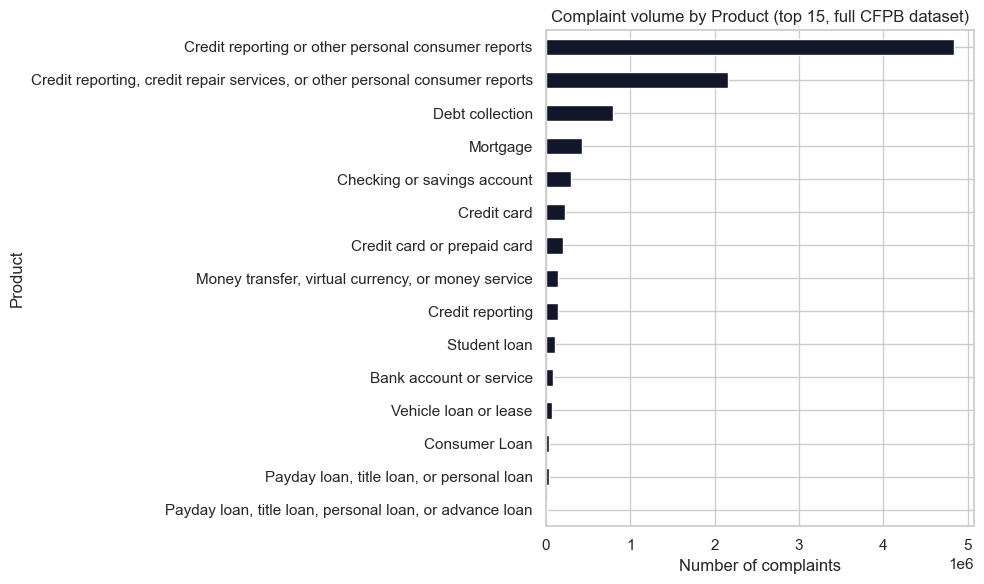

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
eda_stats["product_counts"].head(15).plot(kind="barh", ax=ax, color="#12172b")
ax.set_xlabel("Number of complaints")
ax.set_title("Complaint volume by Product (top 15, full CFPB dataset)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Narrative presence — with vs. without text

Not every complaint includes a free-text narrative. Since the RAG pipeline is built entirely on narrative text, complaints without one are dropped.

With narrative:    2,980,756
Without narrative: 6,629,041
Narrative coverage: 31.0%


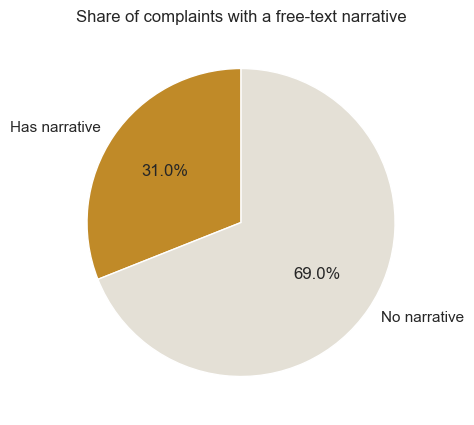

In [11]:
print(f"With narrative:    {eda_stats['with_narrative']:,}")
print(f"Without narrative: {eda_stats['without_narrative']:,}")
total = eda_stats['with_narrative'] + eda_stats['without_narrative']
print(f"Narrative coverage: {eda_stats['with_narrative'] / total:.1%}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [eda_stats["with_narrative"], eda_stats["without_narrative"]],
    labels=["Has narrative", "No narrative"],
    autopct="%1.1f%%",
    colors=["#c08a28", "#e4e0d6"],
    startangle=90,
)
ax.set_title("Share of complaints with a free-text narrative")
plt.show()

> **If narrative coverage looks very low (well under ~10%):** double-check that
> `data/raw/complaints.csv` is the full historical CFPB export, not a recent,
> date-limited slice — recent complaints (especially credit-reporting disputes) have
> much lower narrative-consent rates than the historical average. If needed,
> re-download with `has_narrative=true` applied server-side at CFPB's API, or grab
> the full bulk file rather than a windowed export.


## 4. Narrative length distribution

Word count matters directly for the Task 2 chunking decision.

In [12]:
print(eda_stats["word_count"])

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
dtype: float64


The full distribution histogram (not just this summary) is shown in section 6, computed on the smaller filtered dataset — plotting a histogram from the raw streaming pass would mean holding every word count from the full file in memory, which defeats the purpose of streaming. The `describe()` summary above already tells us what we need: median, spread, and tail length.

## 5. Filter to target products + drop empty narratives, then clean text

`load_and_filter()` streams the raw file in chunks (same chunking as the EDA step above) and, for every chunk:
1. Maps `Product` to one of our four canonical target categories via keyword matching
2. Drops rows with no narrative
3. Lowercases + strips CFPB boilerplate (redaction placeholders like `XXXX`, opening filler like *"I am writing to file a complaint..."*)
4. Drops anything near-empty after cleaning

Only matching rows are kept in memory as chunks are processed, so peak memory stays bounded even on a very large raw file.

In [13]:
filtered = load_and_filter()
print(f"Rows after filtering + cleaning: {len(filtered):,}")
filtered["Product"].value_counts()

2026-07-11 10:24:24,692 - INFO - Streaming D:\10 acadamy\rag-complaint-chatbot\data\raw\complaints.csv in chunks of 50,000 rows
2026-07-11 10:24:43,284 - INFO -   ...scanned 500,000 rows, kept 3,193 so far
2026-07-11 10:25:35,385 - INFO -   ...scanned 1,000,000 rows, kept 19,912 so far
2026-07-11 10:26:06,402 - INFO -   ...scanned 1,500,000 rows, kept 32,876 so far
2026-07-11 10:26:46,617 - INFO -   ...scanned 2,000,000 rows, kept 60,213 so far
2026-07-11 10:27:25,004 - INFO -   ...scanned 2,500,000 rows, kept 84,025 so far
2026-07-11 10:27:47,201 - INFO -   ...scanned 3,000,000 rows, kept 97,805 so far
2026-07-11 10:28:14,828 - INFO -   ...scanned 3,500,000 rows, kept 117,155 so far
2026-07-11 10:29:38,427 - INFO -   ...scanned 4,000,000 rows, kept 143,194 so far
2026-07-11 10:30:43,019 - INFO -   ...scanned 4,500,000 rows, kept 171,512 so far
2026-07-11 10:31:45,819 - INFO -   ...scanned 5,000,000 rows, kept 202,479 so far
2026-07-11 10:33:51,083 - INFO -   ...scanned 5,500,000 rows,

Rows after filtering + cleaning: 456,104


Product
Credit card        189296
Savings account    140275
Money transfer      98660
Personal loan       27873
Name: count, dtype: int64

In [14]:
filtered[["Product", "Issue", "cleaned_narrative"]].head(5)

,Product,Issue,cleaned_narrative
0,Credit card,Getting a credit card,a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my na...
1,Savings account,Managing an account,i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside their branch. i went i...
2,Credit card,"Other features, terms, or problems","dear cfpb, i have a secured credit card with citibank which is changed to unsecured card and i have been calling n w..."
3,Credit card,Incorrect information on your report,"i have a citi rewards cards. the credit balance issued to me was 8400.00 . i recently moved, which meant my bills wo..."
4,Credit card,Problem with a purchase shown on your statement,b'i am writing to dispute the following charges on my citi credit card accounts where i have become a victim of iden...


### Sanity check — before / after cleaning, side by side

In [15]:
sample_row = filtered.iloc[0]
print("RAW:\n", sample_row["Consumer complaint narrative"][:400])
print("\nCLEANED:\n", sample_row["cleaned_narrative"][:400])

RAW:
 A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However, they have failed to remove this from the three credit agencies and this fraud is now impacting my 

CLEANED:
 a card was opened under my name by a fraudster. i received a notice from that an account was just opened under my name. i reached out to to state that this activity was unauthorized and not me. confirmed this was fraudulent and immediately closed the card. however, they have failed to remove this from the three credit agencies and this fraud is now impacting my credit score based on a hard credit 


## 6. Narrative length distribution *after* filtering

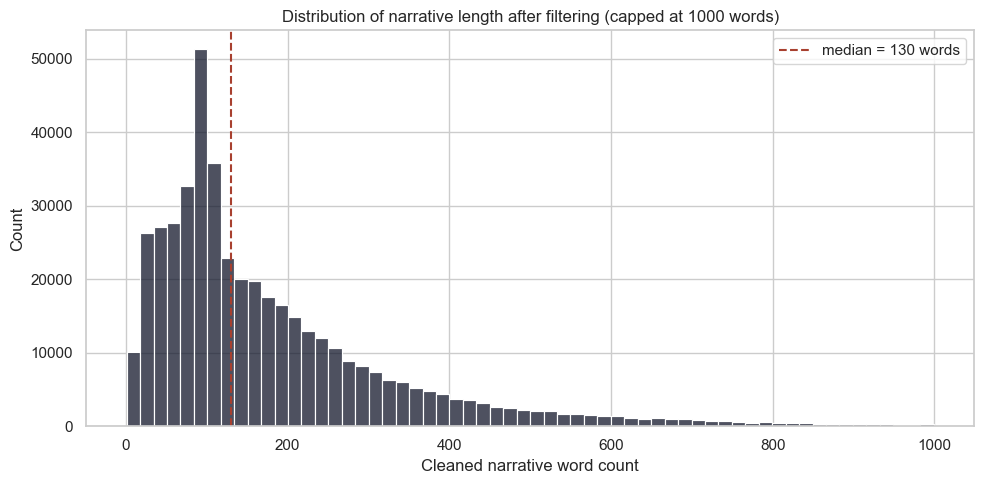

In [16]:
word_counts_filtered = filtered["cleaned_narrative"].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(word_counts_filtered[word_counts_filtered < 1000], bins=60, ax=ax, color="#12172b")
ax.axvline(word_counts_filtered.median(), color="#a8402f", linestyle="--",
           label=f"median = {word_counts_filtered.median():.0f} words")
ax.set_xlabel("Cleaned narrative word count")
ax.set_title("Distribution of narrative length after filtering (capped at 1000 words)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Product distribution after filtering

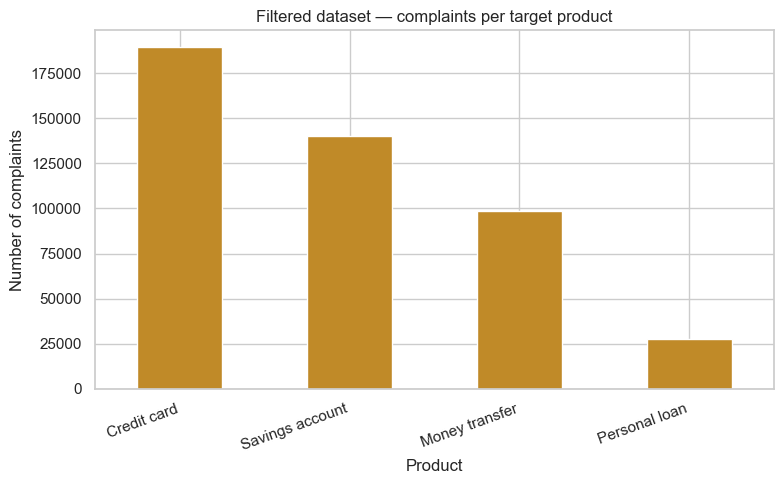

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
filtered["Product"].value_counts().plot(kind="bar", ax=ax, color="#c08a28")
ax.set_ylabel("Number of complaints")
ax.set_title("Filtered dataset — complaints per target product")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 8. Save the cleaned, filtered dataset

In [18]:
config.DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
filtered.to_csv(config.FILTERED_COMPLAINTS_PATH, index=False)
print(f"Saved {len(filtered):,} rows -> {config.FILTERED_COMPLAINTS_PATH}")

Saved 456,104 rows -> D:\10 acadamy\rag-complaint-chatbot\data\processed\filtered_complaints.csv


## Key findings (summary for the report)

*Fill these in with your actual numbers once you run this notebook against the real
`complaints.csv`:*

1. **Product distribution:** [e.g. "Credit card complaints dominate the target scope at
   X%, followed by Personal loan at Y%..."]
2. **Narrative coverage:** [e.g. "Z% of all complaints include a free-text narrative;
   the rest are dropped since the RAG pipeline depends entirely on narrative text."]
3. **Narrative length:** [e.g. "Median narrative length is ~N words, with a long right
   tail — this justified chunking (Task 2) rather than embedding whole narratives as a
   single vector."]
4. **Final filtered dataset size:** [N complaints across the four target products,
   ready for Task 2 sampling.]
